# IMPORTS

In [1]:
import json
import gzip
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string

from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [3]:
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

# LOAD DATA

In [5]:
DATA_PATH = "data/Appliances_5.json.gz"

def load_amazon_gz(path):
    """Load a gzipped JSON-lines file into a DataFrame."""
    records = []
    with gzip.open(path, "rb") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)


df = load_amazon_gz(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]} reviews, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}\n")

Dataset loaded: 2277 reviews, 12 columns
Columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'image']



# DATA EXPLORATION

In [6]:
print("\n--- Basic Info ---")
print(df.dtypes)
print(f"\nTotal reviews       : {len(df)}")
print(f"Unique products     : {df['asin'].nunique()}")
print(f"Unique reviewers    : {df['reviewerID'].nunique()}")
print(f"Date range          : {df['reviewTime'].min()} – {df['reviewTime'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


--- Basic Info ---
overall           float64
verified             bool
reviewTime            str
reviewerID            str
asin                  str
style              object
reviewerName          str
reviewText            str
summary               str
unixReviewTime      int64
vote                  str
image              object
dtype: object

Total reviews       : 2277
Unique products     : 48
Unique reviewers    : 47
Date range          : 01 1, 2015 – 12 6, 2016

Missing values:
overall              0
verified             0
reviewTime           0
reviewerID           0
asin                 0
style             2239
reviewerName         0
reviewText           0
summary              0
unixReviewTime       0
vote               203
image             1449
dtype: int64


In [7]:
print("\n--- Rating Distribution ---")
print(df["overall"].value_counts().sort_index())


--- Rating Distribution ---
overall
1.0       9
2.0      13
3.0     421
4.0     222
5.0    1612
Name: count, dtype: int64


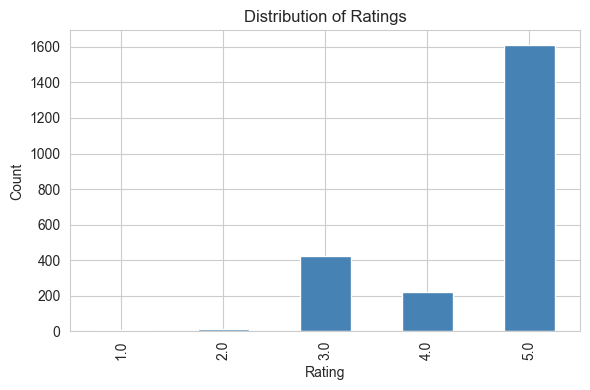

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
df["overall"].value_counts().sort_index().plot(kind="bar", color="steelblue", ax=ax)
ax.set_title("Distribution of Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/rating_distribution.png", dpi=150)
plt.show()

In [11]:
reviews_per_product = df.groupby("asin").size()
print("\n--- Reviews Per Product ---")
print(reviews_per_product.describe())


--- Reviews Per Product ---
count      48.000000
mean       47.437500
std       293.747388
min         1.000000
25%         2.000000
50%         5.000000
75%         7.000000
max      2040.000000
dtype: float64


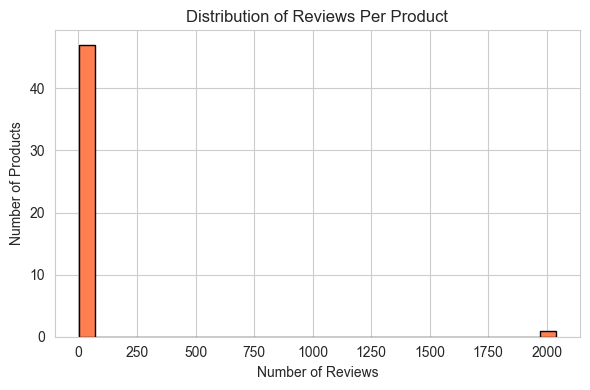

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
reviews_per_product.hist(bins=30, color="coral", edgecolor="black", ax=ax)
ax.set_title("Distribution of Reviews Per Product")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Number of Products")
plt.tight_layout()
plt.savefig("outputs/reviews_per_product.png", dpi=150)
plt.show()

In [13]:
reviews_per_user = df.groupby("reviewerID").size()
print("\n--- Reviews Per User ---")
print(reviews_per_user.describe())


--- Reviews Per User ---
count     47.000000
mean      48.446809
std       82.799341
min        5.000000
25%        5.000000
50%        6.000000
75%        8.000000
max      206.000000
dtype: float64


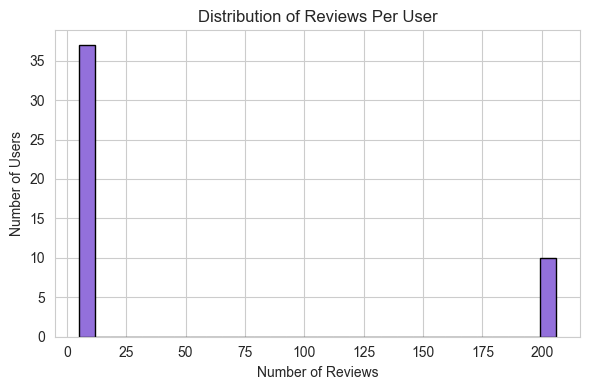

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
reviews_per_user.hist(bins=30, color="mediumpurple", edgecolor="black", ax=ax)
ax.set_title("Distribution of Reviews Per User")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Number of Users")
plt.tight_layout()
plt.savefig("outputs/reviews_per_user.png", dpi=150)
plt.show()

In [15]:
df["reviewText"] = df["reviewText"].fillna("")
df["review_length"] = df["reviewText"].apply(len)
df["review_word_count"] = df["reviewText"].apply(lambda x: len(x.split()))

print("\n--- Review Length (characters) ---")
print(df["review_length"].describe())

print("\n--- Review Word Count ---")
print(df["review_word_count"].describe())


--- Review Length (characters) ---
count    2277.000000
mean     1481.945103
std       848.284016
min         2.000000
25%       971.000000
50%      1198.000000
75%      1864.000000
max      3932.000000
Name: review_length, dtype: float64

--- Review Word Count ---
count    2277.000000
mean      287.505929
std       161.640463
min         1.000000
25%       188.000000
50%       242.000000
75%       371.000000
max       650.000000
Name: review_word_count, dtype: float64


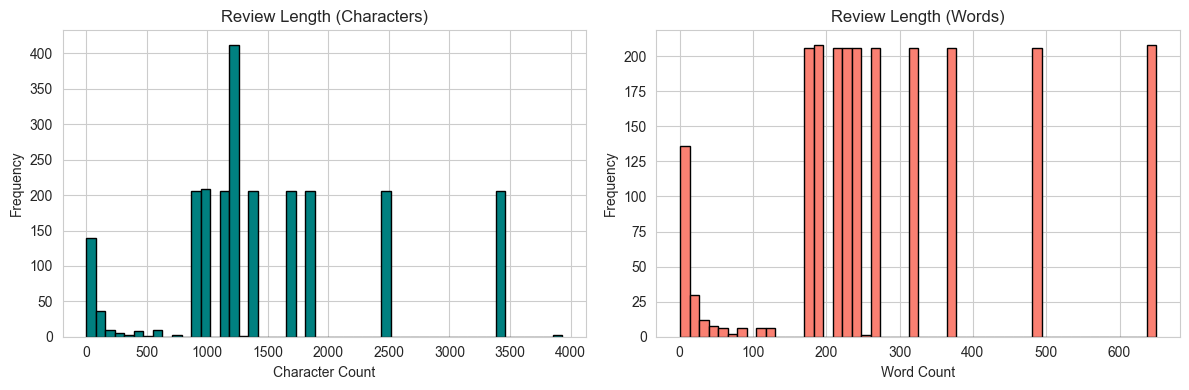

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["review_length"].hist(bins=50, color="teal", edgecolor="black", ax=axes[0])
axes[0].set_title("Review Length (Characters)")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

df["review_word_count"].hist(bins=50, color="salmon", edgecolor="black", ax=axes[1])
axes[1].set_title("Review Length (Words)")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("outputs/review_lengths.png", dpi=150)
plt.show()


--- Outliers (IQR method on word count) ---
Lower bound: -86, Upper bound: 646
Number of outlier reviews: 208


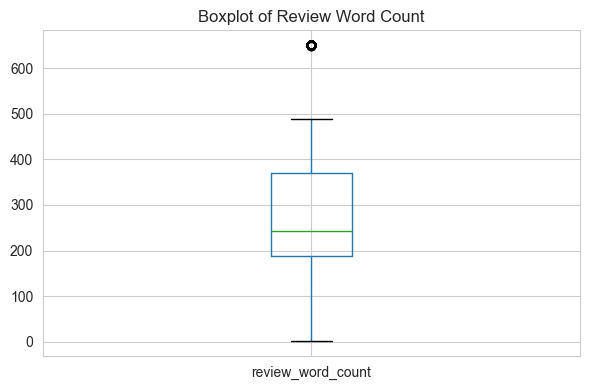

In [17]:
q1 = df["review_word_count"].quantile(0.25)
q3 = df["review_word_count"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[
    (df["review_word_count"] < lower_bound)
    | (df["review_word_count"] > upper_bound)
]
print(f"\n--- Outliers (IQR method on word count) ---")
print(f"Lower bound: {lower_bound:.0f}, Upper bound: {upper_bound:.0f}")
print(f"Number of outlier reviews: {len(outliers)}")

fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column="review_word_count", ax=ax)
ax.set_title("Boxplot of Review Word Count")
plt.tight_layout()
plt.savefig("outputs/review_wordcount_boxplot.png", dpi=150)
plt.show()

In [18]:
duplicate_count = df.duplicated(subset=["reviewerID", "asin", "reviewText"]).sum()
print(f"\n--- Duplicates ---")
print(f"Duplicate reviews (same user, product, text): {duplicate_count}")

# Remove exact duplicates if any
df = df.drop_duplicates(subset=["reviewerID", "asin", "reviewText"]).reset_index(
    drop=True
)
print(f"Dataset after duplicate removal: {len(df)} reviews")

# Average rating
print(f"\n--- Averages ---")
print(f"Mean rating: {df['overall'].mean():.2f}")
print(f"Median rating: {df['overall'].median():.1f}")

# Verified vs unverified
if "verified" in df.columns:
    print(f"\nVerified purchases: {df['verified'].sum()}")
    print(f"Unverified purchases: {(~df['verified']).sum()}")


--- Duplicates ---
Duplicate reviews (same user, product, text): 2074
Dataset after duplicate removal: 203 reviews

--- Averages ---
Mean rating: 4.59
Median rating: 5.0

Verified purchases: 180
Unverified purchases: 23


# TEXT PRE-PROCESSING & LABELING

Label based on rating
We map the star rating to sentiment classes to create ground truth labels for evaluating lexicon-based classifiers.


--- Sentiment Label Distribution ---
sentiment
Positive    178
Negative     16
Neutral       9
Name: count, dtype: int64


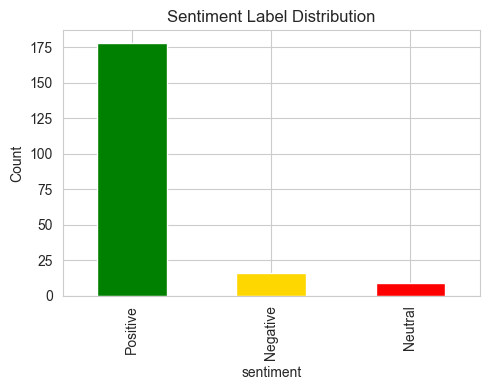

In [19]:
def label_sentiment(rating):
    """Map numeric rating to sentiment label."""
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"


df["sentiment"] = df["overall"].apply(label_sentiment)
print("\n--- Sentiment Label Distribution ---")
print(df["sentiment"].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
df["sentiment"].value_counts().plot(
    kind="bar",
    color=["green", "gold", "red"],
    ax=ax,
)
ax.set_title("Sentiment Label Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/sentiment_distribution.png", dpi=150)
plt.show()

We choose 'reviewText' as the primary column for sentiment analysis because it contains the full customer opinion.  
We also keep 'summary' as it provides a condensed version that can reinforce sentiment signals.
'overall' is kept as ground truth.  'asin' and 'reviewerID' are kept for identification.

In [20]:
COLUMNS_USED = [
    "reviewerID",
    "asin",
    "overall",
    "reviewText",
    "summary",
    "sentiment",
    "review_word_count",
]
df = df[[c for c in COLUMNS_USED if c in df.columns]].copy()
print(f"\nColumns selected for analysis: {df.columns.tolist()}")


Columns selected for analysis: ['reviewerID', 'asin', 'overall', 'reviewText', 'summary', 'sentiment', 'review_word_count']


In [21]:
empty_reviews = (df["reviewText"].str.strip() == "").sum()
print(f"\nEmpty review texts: {empty_reviews}")
# Remove empty reviews
df = df[df["reviewText"].str.strip() != ""].reset_index(drop=True)
print(f"Dataset after removing empty reviews: {len(df)} reviews")


Empty review texts: 0
Dataset after removing empty reviews: 203 reviews


# TEXT PRE-PROCESSING FOR EACH LEXICON

We studied three lexicon packages:

1. VADER (Valence Aware Dictionary and Sentiment Reasoner)
   - Specifically tuned for social media / short informal text
   - Handles capitalization, punctuation emphasis, slang, emojis
   - Returns compound score (-1 to +1)
   - Works well WITHOUT removing stop words or punctuation

2. TextBlob
   - Built on Pattern library and NLTK
   - Returns polarity (-1 to +1) and subjectivity (0 to 1)
   - General-purpose, easy to use
   - Works well on standard English text

3. SentiWordNet
   - Assigns positivity/negativity/objectivity to WordNet synsets
   - Requires POS tagging and word-sense disambiguation
   - More complex to implement; best for fine-grained analysis

CHOSEN: VADER and TextBlob
- VADER excels on informal review text (handles emphasis, negation well)
- TextBlob provides a good general-purpose baseline for comparison
- Both are straightforward to apply and compare
- SentiWordNet was not chosen because it requires complex word-sense
  disambiguation which adds overhead without significant benefit on
  short product reviews.

In [22]:
df["text_for_vader"] = df["reviewText"].str.strip()

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess_for_textblob(text):
    """Clean text for TextBlob analysis."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"<.*?>", "", text)  # remove HTML
    text = re.sub(r"[^a-z\s]", "", text)  # keep only letters & spaces
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if len(t) > 1]
    return " ".join(tokens)

df["text_for_textblob"] = df["reviewText"].apply(preprocess_for_textblob)

print("\n--- Sample (first review) ---")
print(f"Original      : {df['reviewText'].iloc[0][:120]}...")
print(f"For VADER     : {df['text_for_vader'].iloc[0][:120]}...")
print(f"For TextBlob  : {df['text_for_textblob'].iloc[0][:120]}...")


--- Sample (first review) ---
Original      : I like this as a vent as well as something that will keep house warmer in winter.  I sanded it and then painted it the s...
For VADER     : I like this as a vent as well as something that will keep house warmer in winter.  I sanded it and then painted it the s...
For TextBlob  : like this a vent a well a something that will keep house warmer in winter sanded it and then painted it the same color a...


# SAMPLE 1000 REVIEWS

In [23]:
SAMPLE_SIZE = min(1000, len(df))
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"Randomly selected {SAMPLE_SIZE} reviews (random_state=42)")
print(f"Sentiment distribution in sample:\n{df_sample['sentiment'].value_counts()}")

Randomly selected 203 reviews (random_state=42)
Sentiment distribution in sample:
sentiment
Positive    178
Negative     16
Neutral       9
Name: count, dtype: int64


# MODELING – LEXICON APPROACH

In [24]:
print("\n--- VADER Model ---")
vader_analyzer = SentimentIntensityAnalyzer()


def vader_predict(text):
    """Classify sentiment using VADER compound score."""
    scores = vader_analyzer.polarity_scores(text)
    compound = scores["compound"]
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"


df_sample["vader_pred"] = df_sample["text_for_vader"].apply(vader_predict)
df_sample["vader_compound"] = df_sample["text_for_vader"].apply(
    lambda x: vader_analyzer.polarity_scores(x)["compound"]
)

print("VADER predictions (sample):")
print(df_sample["vader_pred"].value_counts())


--- VADER Model ---
VADER predictions (sample):
vader_pred
Positive    171
Neutral      24
Negative      8
Name: count, dtype: int64


In [25]:
print("\n--- TextBlob Model ---")


def textblob_predict(text):
    """Classify sentiment using TextBlob polarity."""
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"


df_sample["textblob_pred"] = df_sample["text_for_textblob"].apply(textblob_predict)
df_sample["textblob_polarity"] = df_sample["text_for_textblob"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

print("TextBlob predictions (sample):")
print(df_sample["textblob_pred"].value_counts())


--- TextBlob Model ---
TextBlob predictions (sample):
textblob_pred
Positive    157
Neutral      44
Negative      2
Name: count, dtype: int64


# VALIDATION & COMPARISON

In [26]:
labels = ["Positive", "Neutral", "Negative"]
y_true = df_sample["sentiment"]

## VADER METRICS


===== VADER Classification Report =====
              precision    recall  f1-score   support

    Positive       0.91      0.87      0.89       178
     Neutral       0.04      0.11      0.06         9
    Negative       0.25      0.12      0.17        16

    accuracy                           0.78       203
   macro avg       0.40      0.37      0.37       203
weighted avg       0.82      0.78      0.79       203



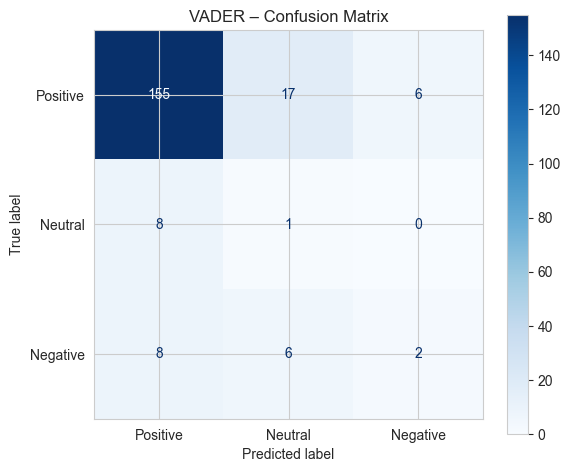

In [ ]:
y_vader = df_sample["vader_pred"]
print("\n===== VADER Classification Report =====")
print(
    classification_report(
        y_true, y_vader, labels=labels, target_names=labels, zero_division=0
    )
)

vader_acc = accuracy_score(y_true, y_vader)
vader_prec = precision_score(y_true, y_vader, average="weighted", zero_division=0)
vader_rec = recall_score(y_true, y_vader, average="weighted", zero_division=0)
vader_f1 = f1_score(y_true, y_vader, average="weighted", zero_division=0)

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_vader = confusion_matrix(y_true, y_vader, labels=labels)
ConfusionMatrixDisplay(cm_vader, display_labels=labels).plot(ax=ax, cmap="Blues")
ax.set_title("VADER – Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/cm_vader.png", dpi=150)
plt.show()

## TextBlob Metrics


===== TextBlob Classification Report =====
              precision    recall  f1-score   support

    Positive       0.90      0.79      0.84       178
     Neutral       0.02      0.11      0.04         9
    Negative       0.50      0.06      0.11        16

    accuracy                           0.70       203
   macro avg       0.47      0.32      0.33       203
weighted avg       0.83      0.70      0.75       203



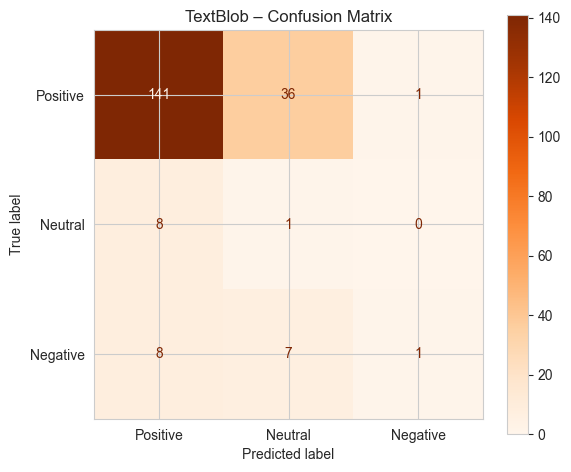

In [28]:
y_textblob = df_sample["textblob_pred"]
print("\n===== TextBlob Classification Report =====")
print(
    classification_report(
        y_true, y_textblob, labels=labels, target_names=labels, zero_division=0
    )
)

tb_acc = accuracy_score(y_true, y_textblob)
tb_prec = precision_score(y_true, y_textblob, average="weighted", zero_division=0)
tb_rec = recall_score(y_true, y_textblob, average="weighted", zero_division=0)
tb_f1 = f1_score(y_true, y_textblob, average="weighted", zero_division=0)

fig, ax = plt.subplots(figsize=(6, 5))
cm_tb = confusion_matrix(y_true, y_textblob, labels=labels)
ConfusionMatrixDisplay(cm_tb, display_labels=labels).plot(ax=ax, cmap="Oranges")
ax.set_title("TextBlob – Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/cm_textblob.png", dpi=150)
plt.show()

## Comparison Table


===== Comparison Table =====
              Metric  VADER TextBlob
            Accuracy 0.7783   0.7044
Precision (weighted) 0.8164   0.8279
   Recall (weighted) 0.7783   0.7044
       F1 (weighted) 0.7947   0.7486


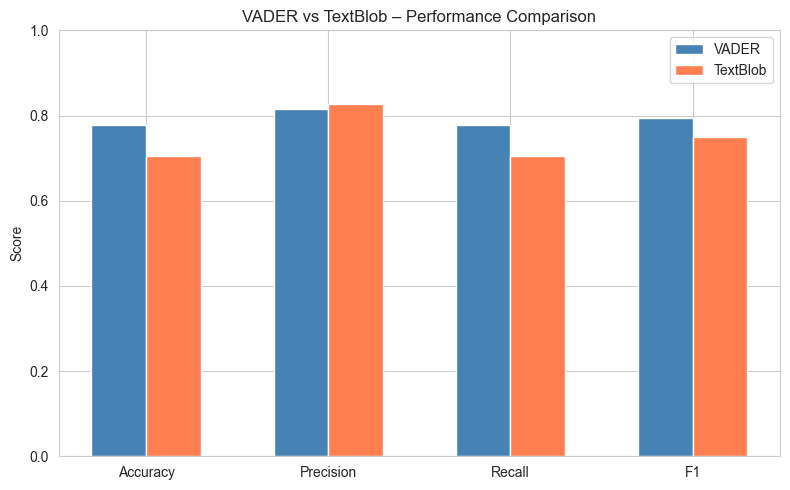

In [ ]:
print("\n===== Comparison Table =====")
comparison = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 (weighted)"],
        "VADER": [
            f"{vader_acc:.4f}",
            f"{vader_prec:.4f}",
            f"{vader_rec:.4f}",
            f"{vader_f1:.4f}",
        ],
        "TextBlob": [
            f"{tb_acc:.4f}",
            f"{tb_prec:.4f}",
            f"{tb_rec:.4f}",
            f"{tb_f1:.4f}",
        ],
    }
)
print(comparison.to_string(index=False))

# Side-by-side bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(4)
width = 0.3
vals_vader = [vader_acc, vader_prec, vader_rec, vader_f1]
vals_tb = [tb_acc, tb_prec, tb_rec, tb_f1]

ax.bar(x - width / 2, vals_vader, width, label="VADER", color="steelblue")
ax.bar(x + width / 2, vals_tb, width, label="TextBlob", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Precision", "Recall", "F1"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("VADER vs TextBlob – Performance Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/comparison_chart.png", dpi=150)
plt.show()

### Score distribution plots

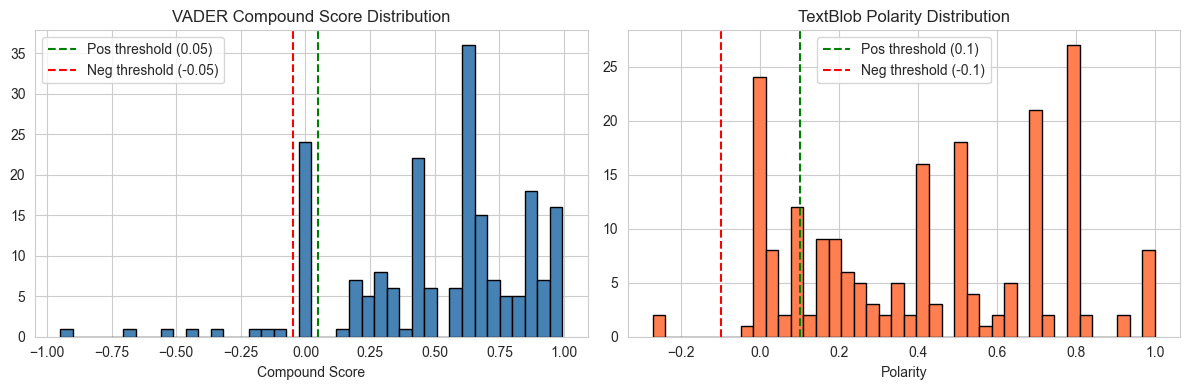

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_sample["vader_compound"], bins=40, color="steelblue", edgecolor="black")
axes[0].axvline(0.05, color="green", linestyle="--", label="Pos threshold (0.05)")
axes[0].axvline(-0.05, color="red", linestyle="--", label="Neg threshold (-0.05)")
axes[0].set_title("VADER Compound Score Distribution")
axes[0].set_xlabel("Compound Score")
axes[0].legend()

axes[1].hist(
    df_sample["textblob_polarity"], bins=40, color="coral", edgecolor="black"
)
axes[1].axvline(0.1, color="green", linestyle="--", label="Pos threshold (0.1)")
axes[1].axvline(-0.1, color="red", linestyle="--", label="Neg threshold (-0.1)")
axes[1].set_title("TextBlob Polarity Distribution")
axes[1].set_xlabel("Polarity")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/score_distributions.png", dpi=150)
plt.show()

In [31]:
df_sample.to_csv("outputs/phase1_results.csv", index=False)
print("\nResults saved to outputs/phase1_results.csv")
print("\nPhase #1 complete!")


Results saved to outputs/phase1_results.csv

Phase #1 complete!
